In [1]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Carga desde un archivo .csv sin indice
bpiso= pd.read_csv('Analisis GAC Full7agosto 2026(Bitacora de Piso).csv') 

In [3]:
#Verificamos información del DataFrame
bpiso.info()

<class 'pandas.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 30 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Fecha                                       198 non-null    str    
 1   Nombre Cliente                              197 non-null    str    
 2   Telefono                                    0 non-null      float64
 3   Asesor                                      196 non-null    str    
 4   Esatus Lead                                 197 non-null    str    
 5   PDM                                         234 non-null    bool   
 6   SDC                                         216 non-null    object 
 7   Estatus de SDC                              2 non-null      str    
 8   Venta                                       216 non-null    object 
 9   Temperatura                                 10 non-null     str    
 10  Inter Gerente            

In [4]:
#Imprimo los primeros 5 registro del dataframe
bpiso.head()

,Fecha,Nombre Cliente,Telefono,Asesor,Esatus Lead,PDM,SDC,Estatus de SDC,Venta,Temperatura,...,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29
0,04/01/2025,Ubaldo Cruz Hernandez,NaN,Aurelio,Activo,True,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,04/01/2025,Olivia Cabello,NaN,Pedro,Activo,False,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,04/02/2025,Ana Laura Espinoza,NaN,Mauricio,Activo,True,True,Analisis,True,Lead Interes Alto,...,NaN,NaN,NaN,NaN,NaN,NaN,Items,Items,items,items
3,04/02/2025,Elvis Sanchez,NaN,Aurelio,Activo,False,False,NaN,False,Lead InteresBajo,...,NaN,NaN,NaN,NaN,NaN,NaN,Aurelio,Activo,Aprobada,Lead Interes Medio
4,04/03/2025,Ariel Fernando López,NaN,Alan,Activo,True,False,NaN,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Pedro,Cerrado,Condicionada,Lead InteresBajo


Bitácora de piso - 5 porques de clientes de piso

In [5]:
Pregunta_5porques = bpiso[
    ["5 porques clientes de piso "]
].copy()

Pregunta_5porques = Pregunta_5porques.dropna()

Pregunta_5porques

,5 porques clientes de piso
0,El cliente llego ocasionalmente antes de llega...
1,Clienta viene buscando opciones para ella y su...
2,El cliente visito la agencia porque iba pasand...
3,El Señor Elvis se encuentra evaluando diferent...
4,El cliente se encuentra en busqueda de renovar...
5,Nuestro cliente es vecino de Lomas de Angelópo...
6,Ingresamos solicitud con los bonos posibles ap...
12,El cliente nos conoció porque un amigo del tra...


In [6]:
# Muestro las respuestas completas de la pregunta abierta

for respuesta in Pregunta_5porques["5 porques clientes de piso "]:
    print(respuesta)
    print("--------------------")

El cliente llego ocasionalmente antes de llegar a Nissan, no ingresa solicitud porque se encuentra viendo opciones, realiza prueba de manejo un familiar pero no directamente la persona que tiene planes de compra porque le da miedo manejar pero no la realiza ella porque le da miedo manejar, no deja más informaicón.
--------------------
Clienta viene buscando opciones para ella y sus hijos, viene sola porque sus hijos no tienen tiempo, realizan cotizaciones porque se encuentra realizando comparativas, no realiza prueba de manejo porque prefiere regresar con sus hijos, las opciones so buenas y pide fichas impresas y cotizaciones, no ingresa SDC porque sus hijos la quieren escoger.
--------------------
El cliente visito la agencia porque iba pasando y le gustaron las camionetas, realizo prueba de manejo porque la atención del Asesor fue muy buena, incluso visito dos veces la agencia ya que el cliente vino por la mañana y regreso en la tarde con sus hijas. Ingresa solicitud de crédito y se 

In [7]:
# Extraigo la pregunta abierta
Pregunta_5porques = bpiso[
    ["5 porques clientes de piso "]
].copy()

# Elimino las respuestas vacías
Pregunta_5porques = Pregunta_5porques.dropna()

Pregunta_5porques

,5 porques clientes de piso
0,El cliente llego ocasionalmente antes de llega...
1,Clienta viene buscando opciones para ella y su...
2,El cliente visito la agencia porque iba pasand...
3,El Señor Elvis se encuentra evaluando diferent...
4,El cliente se encuentra en busqueda de renovar...
5,Nuestro cliente es vecino de Lomas de Angelópo...
6,Ingresamos solicitud con los bonos posibles ap...
12,El cliente nos conoció porque un amigo del tra...


In [8]:
Pregunta_5porques["Caracteristica"] = "Otro"

In [9]:
Pregunta_5porques.loc[

    Pregunta_5porques["5 porques clientes de piso "]
    .str.contains(
        "viendo opciones|buscando opciones|comparativas|"
        "evaluando diferentes opciones|toda la gama",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Exploración y comparación"

In [10]:
Pregunta_5porques.loc[

    Pregunta_5porques["5 porques clientes de piso "]
    .str.contains(
        "renovar su vehículo|renovar su vehiculo|"
        "vehículo similar|vehiculo similar",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Renovación de vehículo"

In [11]:
Pregunta_5porques.loc[

    Pregunta_5porques["5 porques clientes de piso "]
    .str.contains(
        "iba pasando|le queda de paso|"
        "vecino de lomas|refacciones|"
        "llamo la atención la agencia|llamó la atención la agencia",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Interés espontáneo / proximidad"

In [12]:
Pregunta_5porques.loc[

    Pregunta_5porques["5 porques clientes de piso "]
    .str.contains(
        "amigo del trabajo|recomendo el producto|"
        "recomendó el producto",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Recomendación"

In [13]:
Pregunta_5porques.loc[

    Pregunta_5porques["5 porques clientes de piso "]
    .str.contains(
        "rechazado por score|unidad que puede comprar|"
        "formaliza con un mazda",
        case=False,
        regex=True
    ),

    "Caracteristica"

] = "Barrera financiera / crédito"

In [14]:
Pregunta_5porques[
    ["5 porques clientes de piso ", "Caracteristica"]
]

,5 porques clientes de piso,Caracteristica
0,El cliente llego ocasionalmente antes de llega...,Exploración y comparación
1,Clienta viene buscando opciones para ella y su...,Exploración y comparación
2,El cliente visito la agencia porque iba pasand...,Interés espontáneo / proximidad
3,El Señor Elvis se encuentra evaluando diferent...,Renovación de vehículo
4,El cliente se encuentra en busqueda de renovar...,Interés espontáneo / proximidad
5,Nuestro cliente es vecino de Lomas de Angelópo...,Interés espontáneo / proximidad
6,Ingresamos solicitud con los bonos posibles ap...,Barrera financiera / crédito
12,El cliente nos conoció porque un amigo del tra...,Recomendación


In [15]:
Tabla_5porques = (

    Pregunta_5porques["Caracteristica"]
    .value_counts()
    .reset_index()

)

Tabla_5porques

,Caracteristica,count
0,Interés espontáneo / proximidad,3
1,Exploración y comparación,2
2,Renovación de vehículo,1
3,Barrera financiera / crédito,1
4,Recomendación,1


In [16]:
Filtro_5porques = Tabla_5porques[
    Tabla_5porques["count"] > 0
]

Filtro_5porques

,Caracteristica,count
0,Interés espontáneo / proximidad,3
1,Exploración y comparación,2
2,Renovación de vehículo,1
3,Barrera financiera / crédito,1
4,Recomendación,1


In [17]:
Filtro_index_5porques = Filtro_5porques.set_index(
    "Caracteristica"
)

Filtro_index_5porques

,count
Caracteristica,
Interés espontáneo / proximidad,3
Exploración y comparación,2
Renovación de vehículo,1
Barrera financiera / crédito,1
Recomendación,1


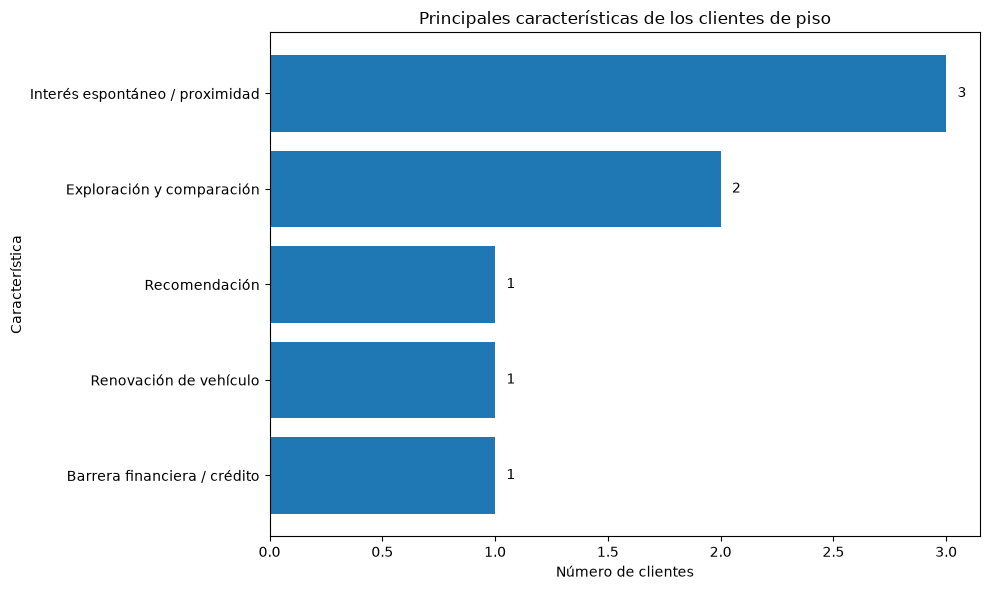

In [18]:

Filtro_index_5porques = Filtro_index_5porques.sort_values(
    by="count",
    ascending=True
)

plt.figure(figsize=(10, 6))

barras = plt.barh(
    Filtro_index_5porques.index,
    Filtro_index_5porques["count"]
)

for barra in barras:

    ancho = barra.get_width()

    plt.text(
        ancho + 0.05,
        barra.get_y() + barra.get_height()/2,
        int(ancho),
        va="center"
    )

plt.title("Principales características de los clientes de piso")
plt.xlabel("Número de clientes")
plt.ylabel("Característica")

plt.tight_layout()
plt.show()